# APPM 4600 HW3 - Charlie Caravati

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

> ## 1.

$\{p_n\}_{n=0}^{\infty}$ converges to p with $p_n \neq p$ for all n. If there exists positive constant $\lambda$ and $\alpha$ such that $\lim_{n \to \infty}\frac{|p_{n+1} - p|}{|p_n - p|^{\alpha}} = \lambda$ then $\{p_n\}_{n=1}^{\infty}$ converges to p with order $\alpha$ and error constant $\lambda$. If $\alpha \lt 1$ then the sequence converges linearly. If $\alpha = 2$ the sequence is quadratically convergent.

Which of the following will converge to the fixed point $x_*$. Give order of converge and rate for linear.

> ### (a) $x_{n+1} = -16 + 6x_n + \frac{12}{x_n}, x_* = 2$

$g'(x) = 6 - \frac{12}{x_n^2}$

$g'(2) = 6 - \frac{12}{4} = 6 - 3 = 3 \gt 1$

The sequence does not converge to the fixed point.


> ### (b) $x_{n+1} = \frac{2}{3}x_n + \frac{1}{x_n^2}, x_* = 3^{\frac{1}{3}}$

$g'(x) = \frac{2}{3} - \frac{2}{x_n^3}$

$g'(3^{\frac{1}{3}}) = \frac{2}{3} - \frac{2}{(3^{\frac{1}{3}})^3} = \frac{2}{3} - \frac{2}{3} = 0$

$g''(x) = \frac{6}{x_n^4}$

$g''(3^{\frac{1}{3}}) = \frac{6}{3^{(\frac{1}{3}})^4} = \frac{6}{3^{\frac{4}{3}}} \neq 0$

Since $g'(x_*) = 0$ and $g''(x_*) \neq 0$ the sequence converges quadratically with order $\alpha = 2$


> ### (c) $x_{n+1} = \frac{12}{1+x_n}, x_* = 3$

$g'(x) = - \frac{12}{(1+x_n)^2}$

$g'(3) = - \frac{12}{(1+3)^2} = -\frac{12}{16} = - \frac{3}{4} \to |- \frac{3}{4}| \lt 1$

Since $|g'(x_*)| = \frac{3}{4} \lt 1$, the sequence converges linearly with rate $\alpha = \frac{3}{4}$

> ## 2.

$\frac{T(x,t) - T_s}{T_i - T_s} = $ erf $(\frac{x}{2\sqrt{\alpha t}})$

erf $(t) = \frac{2}{\sqrt{\pi}}\int_0^t{exp(-s^2)ds}$

$T_i = 20, T_s = -15, \alpha = 0.138•10^{-6}, \epsilon = 10^{-13}$

> ### (a)

We need to find x such that $T(x,t) = 0$

$\frac{0 - (-15)}{20 - (-15)} = \frac{15}{35} = \frac{3}{7} = $ erf $(\frac{x}{2\sqrt{\alpha t}}) \to $

$f(x) = $ erf $(\frac{x}{2\sqrt{\alpha t}}) - \frac{3}{7} = 0$

$f'(x) = \frac{2}{\sqrt{\pi}} exp(-(\frac{x}{2\sqrt{\alpha t}})^2) (\frac{1}{2\sqrt{\alpha t}}) = \frac{1}{\sqrt{\pi \alpha t}} exp (- \frac{x^2}{4 \alpha t})$



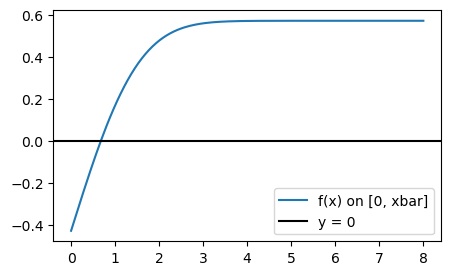

In [24]:
# plot f(x) on [0. xbar] where xbar is chosen such that f(x) > 0

alpha = .138e-6
days = 60
t = days * 24 * 60 * 60

f = lambda x: erf(x / (2 * np.sqrt(alpha * t))) - (3/7)

xbar = 8

x_vals = np.linspace(0, xbar, 200)
y_vals = f(x_vals)


plt.figure(figsize=(5,3))
plt.plot(x_vals, y_vals, label = "f(x) on [0, xbar]")
plt.axhline(0, color="black", linestyle="-", label="y = 0")
plt.legend()

In [25]:
def bisection(f, a, b, tol, nmax):

    # first verify there is a root we can find in the interval
    fa = f(a)
    fb = f(b)
    if (fa*fb>0):
        ier = 1
        astar = a
        return [astar, ier]
    
    # verify end points are not a root
    if (fa == 0):
        astar = a
        ier =0
        return [astar, ier]
    
    if (fb ==0):
        astar = b
        ier = 0
        return [astar, ier]
    
    d = 0.5*(a+b)

    count = 0

    while (abs(d-a) > tol) and count < nmax:
        fd = f(d)
        if (fd ==0):
            astar = d
            ier = 0
            return [astar, ier]
        if (fa*fd<0):
            b = d
        else:
            a = d
            fa = fd
        d = .5 * (a + b)
        count += 1

    astar = d

    if count < nmax:
        ier = 0
        return [astar, ier]
    else:
        ier = 1
        return [astar, ier]

In [30]:
f = lambda x: erf(x / (2 * np.sqrt(alpha * t))) - (3/7)
xbar = 3
epsilon = 10e-13

In [37]:
bisec_root, error = bisection(f, 0, xbar, epsilon, 10000)

print(f"The estimated root is {bisec_root} with error code {error}")

The estimated root is 0.6769618544819878 with error code 0


In [35]:
def newt(f, fp, p0, tol, nmax):
    for i in range(nmax):
        p1 = p0-f(p0)/fp(p0)
        if (abs(p1-p0) < tol):
            pstar = p1
            return pstar
        p0 = p1
    pstar = p1
    return pstar

In [45]:
f = lambda x: erf(x / (2 * np.sqrt(alpha * t))) - (3/7)
fp = lambda x: (1/(np.sqrt(np.pi * alpha * t))) * np.exp(-((x**2)/(4*alpha*t)))
xbar = 3
epsilon = 10e-13

In [43]:
newt_root = newt(f, fp, .01, epsilon, 10000)

print(f"The newton root is {newt_root}")

The newton root is 0.6769618544819366


In [46]:
bar_root = newt(f, fp, xbar, epsilon, 10000)

print(f"The newton root is starting from xbar is {bar_root}")

The newton root is starting from xbar is nan


/var/folders/nm/zhg7jf3n4gz76nqmv2nbzvrr0000gn/T/ipykernel_53562/4293118276.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  p1 = p0-f(p0)/fp(p0)
/var/folders/nm/zhg7jf3n4gz76nqmv2nbzvrr0000gn/T/ipykernel_53562/4293118276.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  p1 = p0-f(p0)/fp(p0)


When starting with too large an $x_0$, $exp(-\frac{x^2}{4 \alpha t})$ becomes increasingly close to zero which triggers an error in the newton iteration as fp(p0) evaluates to 0.

> # 3.

> (a) formal mathematical definition of what it means for $\alpha$ to be a root of multiplicity $m$ of $f(x)$

Let $\alpha$ be a real number and $f(x)$ be a function that is $m$ times continuously differentiable on an open interval containing $\alpha$ and $m$ is a positive integer. $\alpha$ is a roof of multiplicity $m$ of $f(x) = 0$ if it satisfies two conditions. 

First, $f(x)$ can be factored as $f(x) = (x - a)^m g(x)$ where $g(x)$ is continuous at $\alpha$ and $ g(\alpha) \neq 0$. 

Secondly, f(x) and the first m-1 derivatives evaluated at $\alpha$ must equal to 0 with the m derivate at $\alpha$ not equal to 0.

 $ f(\alpha) = 0, f'(\alpha) = 0, , f''(\alpha) = 0, ... , f^{m-1}(\alpha) = 0$ AND $f^m({\alpha}) \neq 0$

 > (b) show that newton's method applied to f(x) only converges linearly to the root $\alpha$

For Newton's, $g(x) = x - \frac{f(x)}{f'(x)}$

$g'(x) = 1 - \frac{f'(x)^2 - f(x)f''(x)}{f'(x)^2} = \frac{f(x)f''(x)}{f'(x)^2}$

For root $\alpha$ and multiplicity $m$ near $\alpha$, $f(x) = c(x-\alpha)^m, f'(x) = cm(x-\alpha)^{m-1},f''(x) = cm(m-1)(x-\alpha)^{m-2} $

$g'(\alpha) = \lim_{x \to \alpha}{\frac{(c(x-\alpha)^m)(cm(m-1)(x-\alpha)^{m-2})}{(cm(x-\alpha)^{m-1})^2}} = \lim_{x \to \alpha}{\frac{m(m-1)c^2(x-\alpha)^{2m-2}}{m^2c^2(x-\alpha)^{2m-2}}} = \frac{m-1}{m}$

Since $0 \lt g'(\alpha)= \frac{m-1}{m} \lt 1$, the function converges linearly with rate $\frac{m-1}{m}$

> (c) show fixed point iteration on $g(x) = x - m \frac{f(x)}{f'(x)}$ is second order convergent

$g'(x) = 1 - m(1 - \frac{f(x)f''(x)}{f'(x)^2}) = 1 - m + m\frac{f(x)f''(x)}{f'(x)^2}$

Plugging in the same $f(x) = c(x-\alpha)^m, f'(x) = cm(x-\alpha)^{m-1},f''(x) = cm(m-1)(x-\alpha)^{m-2}$ simplified above gives

$g'(x) = 1 - m + m(\frac{m-1}{m}) = 1 - m + (m - 1) = 0$

> (d) 

The modified Newton's method in part (c) allows us to return quadratic convergence to Newton's method even when multiplicity is higher than 1. 

> # 4. 

In [50]:
f = lambda x: np.exp(3*x) - 27*x**6 + 27*x**4*np.exp(x) - 9*x**2*np.exp(2*x)
fp = lambda x: 3*np.exp(3*x) - 162*x**5 + 27*(x**4 + 4*x**3)*np.exp(x) - 18*(x**2 + x)*np.exp(2*x)
f2p = lambda x: 9*np.exp(3*x) - 810*x**4 + 27*(x**4 + 8*x**3 + 12*x**2)*np.exp(x) - 18*(2*x**2 + 4*x + 1)*np.exp(2*x)
a = 3
b = 5

In [70]:
def bisec_newt(f,fp, f2p, a,b, nmax, tol):

    # first verify there is a root we can find in the interval
    fa = f(a)
    fb = f(b)
    if (fa*fb>0):
        ier = 1
        astar = a
        return [astar, ier]
    
    # verify end points are not a root
    if (fa == 0):
        astar = a
        ier =0
        return [astar, ier]
    
    if (fb ==0):
        astar = b
        ier = 0
        return [astar, ier]
    
    d = 0.5*(a+b)
    fd = f(d)
    fpd = fp(d)
    f2pd = f2p(d)

    count = 0

    while (((fd * f2pd)/(fpd**2)) > 1) and count < nmax:
        count += 1
        d = 0.5*(a+b)
        fd = f(d)
        fpd = fp(d)
        f2pd = f2p(d)
        if (fd ==0):
            astar = d
            ier = 0
            return [astar, ier]
        if (fa*fd<0):
            b = d
        else:
            a = d
            fa = fd
    p0 = d
    ier = 0
    
    # Newton Method
    count = 0
    for i in range(nmax):
        count += 1
        p1 = p0-f(p0)/fp(p0)
        if (abs(p1-p0) < tol):
            pstar = p1
            return [pstar, count]
        p0 = p1
    pstar = p1
    return [pstar, count]

In [66]:
def mod_newt(f, fp, p0, m, tol, nmax):
    count = 0
    for i in range(nmax):
        p1 = p0 - m * (f(p0)/fp(p0))
        if (abs(p1-p0) < tol):
            pstar = p1
            return [pstar, count]
        p0 = p1
        count +=1
    pstar = p1
    return [pstar, count]

In [73]:
root, num = bisec_newt(f, fp, f2p, a, b, 10000, epsilon)

root

np.float64(3.7330715113917687)

In [74]:
mod_root, count = mod_newt(f, fp, a, 3, epsilon, 10000)
root


np.float64(3.7330715113917687)

Unsurprisingly, the modified newton code converges the fastest but requires calculating m or recognizing $f(x) = (e^x-3x^2)^3$ has root multiplicity of 3.